# 04 · Red neuronal MLP tabular

Este notebook estudia si una red neuronal multicapa, o MLP, puede mejorar la predicción obtenida por los modelos lineales. Se comparan las tres configuraciones descritas en la memoria inicial y una cuarta configuración regularizada incorporada al benchmark final.

Todas las redes utilizan las mismas 7.269 observaciones, las mismas 36 variables y los mismos cinco periodos temporales del notebook 03. También se mantiene `PIR_target` como objetivo y la regla de elegibilidad 3/5. De esta forma, las diferencias de resultados dependen de la configuración de la red y no de un cambio en los datos o en la evaluación.

Cada configuración se entrena con tres semillas. Una semilla fija el punto de partida aleatorio de la red; repetir el proceso permite comprobar si el resultado es estable y evita apoyar la conclusión en una única inicialización favorable.

In [1]:
from pathlib import Path
import platform
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").is_dir() and (candidate / "reports").is_dir():
            return candidate
    raise FileNotFoundError("No se encontró el raíz del proyecto (data/raw y reports).")

ROOT = find_project_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")
print({"root": str(ROOT), "python": sys.version.split()[0], "pandas": pd.__version__, "platform": platform.platform()})

import os
import shutil
import time

os.environ["TF_DETERMINISTIC_OPS"] = "1"
import tensorflow as tf
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEEDS = [42, 123, 2026]
TABLE_DIR = ROOT / "reports" / "tables" / "04_mlp"
FIGURE_DIR = ROOT / "reports" / "figures" / "04_mlp"
TENSORBOARD_DIR = ROOT / "reports" / "tensorboard" / "04_mlp"
for directory in [TABLE_DIR, FIGURE_DIR, TENSORBOARD_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

dataset = pd.read_csv(PROCESSED_DIR / "player_pregame_target_game_3_5_1718.csv", parse_dates=["target_date"])
schedule = pd.read_csv(ROOT / "reports" / "tables" / "03_ml_benchmark" / "fold_schedule.csv", parse_dates=["train_end", "test_start", "test_end"])
ml_metrics = pd.read_csv(ROOT / "reports" / "tables" / "03_ml_benchmark" / "metrics_by_fold_competition.csv")
assert len(dataset) == 7_269 and len(schedule) == 5

devices = pd.DataFrame([{"device": device.name, "type": device.device_type} for device in tf.config.list_physical_devices()])
environment = pd.DataFrame([{
    "python": sys.version.split()[0], "tensorflow": tf.__version__, "device_types": ",".join(devices["type"]),
    "seeds": ";".join(map(str, SEEDS)), "experiment_count": 4, "outer_folds": len(schedule),
}])
environment.to_csv(TABLE_DIR / "run_environment.csv", index=False)
display(environment, devices)

{'root': 'C:\\Users\\pablo\\OneDrive\\Documentos\\TFM\\tfm-scouting-ml-dl', 'python': '3.12.4', 'pandas': '2.2.2', 'platform': 'Windows-10-10.0.19045-SP0'}


,python,tensorflow,device_types,seeds,experiment_count,outer_folds
0,3.12.4,2.18.0,CPU,42;123;2026,4,5


,device,type
0,/physical_device:CPU:0,CPU


## Variables y preprocesado por fold

La entrada coincide con la utilizada en el notebook 03: la competición, 34 medias históricas y los días de descanso. La competición se transforma en indicadores numéricos, los valores ausentes se completan con la mediana y las variables numéricas se llevan a una escala comparable.

Este preprocesado se aprende únicamente con los datos de entrenamiento de cada fold. Primero se ajusta con el bloque empleado para seleccionar el número de epochs y después se vuelve a ajustar con todo el entrenamiento. El periodo futuro reservado para test nunca interviene en estas decisiones.

In [2]:
rolling_features = sorted(column for column in dataset if "_roll" in column and not column.endswith("_count"))
FEATURES = ["competition", *rolling_features, "rest_days_player"]
NUMERIC_FEATURES = [column for column in FEATURES if column != "competition"]
assert len(FEATURES) == 36

def make_preprocessor():
    return ColumnTransformer([
        ("competition", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["competition"]),
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), NUMERIC_FEATURES),
    ])

def fold_indices(frame, schedule_row):
    dates = pd.to_datetime(frame["target_date"])
    train = np.flatnonzero(dates <= schedule_row["train_end"])
    test = np.flatnonzero((dates >= schedule_row["test_start"]) & (dates <= schedule_row["test_end"]))
    assert dates.iloc[train].max() < dates.iloc[test].min()
    return train, test

## Configuraciones neuronales

Las cuatro configuraciones se definen antes del entrenamiento. `MLP_base_MAE` reproduce la red base entrenada con pérdida MAE. `MLP_small_RLR_MAE` reduce el tamaño de la red y utiliza `ReduceLROnPlateau`, que disminuye el ritmo de aprendizaje cuando la validación deja de mejorar. `MLP_small_RLR_Huber` mantiene esa arquitectura y sustituye MAE por la pérdida Huber, menos sensible a errores extremos. `MLP_current_MAE` representa la configuración regularizada añadida al benchmark final.

Las variantes `MLP_small_RLR_MAE` y `MLP_small_RLR_Huber` solo se diferencian en la función de pérdida, por lo que permiten estudiar ese cambio de forma directa. En las demás comparaciones cambian varios elementos a la vez y deben analizarse como configuraciones completas. La capa de salida es lineal porque PIR es una variable continua que también puede tomar valores negativos.

In [3]:
EXPERIMENTS = [
    {
        "model": "MLP_base_MAE", "hidden": (256, 128, 64), "batch_norm": True,
        "dropout": 0.25, "l2": 1e-4, "loss": "mae", "reduce_lr": False,
        "max_epochs": 300, "patience": 25, "batch_size": 256,
    },
    {
        "model": "MLP_small_RLR_MAE", "hidden": (128, 64, 32), "batch_norm": True,
        "dropout": 0.35, "l2": 3e-4, "loss": "mae", "reduce_lr": True,
        "max_epochs": 300, "patience": 25, "batch_size": 256,
    },
    {
        "model": "MLP_small_RLR_Huber", "hidden": (128, 64, 32), "batch_norm": True,
        "dropout": 0.35, "l2": 3e-4, "loss": "huber", "reduce_lr": True,
        "max_epochs": 300, "patience": 25, "batch_size": 256,
    },
    {
        "model": "MLP_current_MAE", "hidden": (128, 64, 32), "batch_norm": False,
        "dropout": 0.35, "l2": 3e-4, "loss": "mae", "reduce_lr": False,
        "max_epochs": 80, "patience": 8, "batch_size": 64,
    },
]

def build_mlp(input_width, seed, experiment):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    inputs = tf.keras.Input(shape=(input_width,), name="tabular_features")
    values = inputs
    for units in experiment["hidden"]:
        values = tf.keras.layers.Dense(units, kernel_regularizer=tf.keras.regularizers.l2(experiment["l2"]))(values)
        if experiment["batch_norm"]:
            values = tf.keras.layers.BatchNormalization()(values)
        values = tf.keras.layers.Activation("relu")(values)
        values = tf.keras.layers.Dropout(experiment["dropout"])(values)
    outputs = tf.keras.layers.Dense(1, name="pir_prediction")(values)
    model = tf.keras.Model(inputs, outputs, name=experiment["model"])
    loss = tf.keras.losses.Huber(delta=1.0) if experiment["loss"] == "huber" else "mae"
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=loss, metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")])
    return model

experiment_manifest = pd.DataFrame([{
    **{key: value for key, value in experiment.items() if key != "hidden"},
    "hidden": "-".join(map(str, experiment["hidden"])),
    "optimizer": "Adam; initial_lr=0.001",
    "validation": "last 15% temporal of outer train",
    "evaluation": "5 outer folds; seeds=42,123,2026",
} for experiment in EXPERIMENTS])
experiment_manifest.to_csv(TABLE_DIR / "experiment_manifest.csv", index=False)
display(experiment_manifest)

,model,batch_norm,dropout,l2,loss,reduce_lr,max_epochs,patience,batch_size,hidden,optimizer,validation,evaluation
0,MLP_base_MAE,True,0.25,0.0001,mae,False,300,25,256,256-128-64,Adam; initial_lr=0.001,last 15% temporal of outer train,"5 outer folds; seeds=42,123,2026"
1,MLP_small_RLR_MAE,True,0.35,0.0003,mae,True,300,25,256,128-64-32,Adam; initial_lr=0.001,last 15% temporal of outer train,"5 outer folds; seeds=42,123,2026"
2,MLP_small_RLR_Huber,True,0.35,0.0003,huber,True,300,25,256,128-64-32,Adam; initial_lr=0.001,last 15% temporal of outer train,"5 outer folds; seeds=42,123,2026"
3,MLP_current_MAE,False,0.35,0.0003,mae,False,80,8,64,128-64-32,Adam; initial_lr=0.001,last 15% temporal of outer train,"5 outer folds; seeds=42,123,2026"


## Selección de epochs y entrenamiento final

Dentro de cada fold, el 15 % más reciente del entrenamiento se reserva como validación interna. El entrenamiento se detiene cuando el error deja de mejorar y se conserva el número de epochs que produjo el menor MAE de validación. Después se reconstruye la red y se entrena con todo el bloque de entrenamiento durante ese número de epochs antes de evaluar el periodo futuro.

TensorBoard registra la evolución de la pérdida y del MAE tanto durante la selección como durante el entrenamiento final. Los registros se guardan en `reports/tensorboard/04_mlp/` y las curvas también se exportan a CSV para poder documentarlas o recrearlas con otra herramienta.

In [4]:
ordered = dataset.sort_values(["target_date", "competition", "player_id", "match_id"]).reset_index(drop=True)
X = ordered[FEATURES]
y = pd.to_numeric(ordered["PIR_target"], errors="raise").to_numpy(dtype=np.float32)
metric_rows, prediction_frames, history_rows = [], [], []

class LearningRateRecorder(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.values = []

    def on_epoch_begin(self, epoch, logs=None):
        self.values.append(float(tf.keras.backend.get_value(self.model.optimizer.learning_rate)))

for experiment in EXPERIMENTS:
    model_name = experiment["model"]
    for seed in SEEDS:
        for _, schedule_row in schedule.iterrows():
            fold = int(schedule_row["fold"])
            train_idx, test_idx = fold_indices(ordered, schedule_row)
            validation_size = max(1, int(len(train_idx) * 0.15))
            core_idx, validation_idx = train_idx[:-validation_size], train_idx[-validation_size:]
            run_dir = TENSORBOARD_DIR / model_name / f"seed_{seed}" / f"fold_{fold}"
            if run_dir.exists():
                shutil.rmtree(run_dir)

            selection_preprocessor = make_preprocessor()
            X_core = selection_preprocessor.fit_transform(X.iloc[core_idx]).astype(np.float32)
            X_validation = selection_preprocessor.transform(X.iloc[validation_idx]).astype(np.float32)
            start = time.perf_counter()
            selection_model = build_mlp(X_core.shape[1], seed + fold, experiment)
            lr_recorder = LearningRateRecorder()
            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor="val_loss", patience=experiment["patience"], restore_best_weights=True
                ),
                lr_recorder,
                tf.keras.callbacks.TensorBoard(log_dir=run_dir / "selection", histogram_freq=0, write_graph=True),
            ]
            if experiment["reduce_lr"]:
                callbacks.insert(1, tf.keras.callbacks.ReduceLROnPlateau(
                    monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5, verbose=0
                ))
            selection_history = selection_model.fit(
                X_core, y[core_idx], validation_data=(X_validation, y[validation_idx]),
                epochs=experiment["max_epochs"], batch_size=experiment["batch_size"],
                shuffle=False, verbose=0, callbacks=callbacks,
            )
            best_epoch = int(np.argmin(selection_history.history["val_loss"]) + 1)

            final_preprocessor = make_preprocessor()
            X_train = final_preprocessor.fit_transform(X.iloc[train_idx]).astype(np.float32)
            X_test = final_preprocessor.transform(X.iloc[test_idx]).astype(np.float32)
            final_model = build_mlp(X_train.shape[1], seed + fold, experiment)
            final_callbacks = [
                tf.keras.callbacks.TensorBoard(log_dir=run_dir / "final", histogram_freq=0, write_graph=True)
            ]
            if experiment["reduce_lr"]:
                selected_lr = lr_recorder.values[:best_epoch]
                final_callbacks.append(tf.keras.callbacks.LearningRateScheduler(
                    lambda epoch, current_lr, values=selected_lr: values[min(epoch, len(values) - 1)]
                ))
            final_model.fit(
                X_train, y[train_idx], epochs=best_epoch, batch_size=experiment["batch_size"],
                shuffle=False, verbose=0, callbacks=final_callbacks,
            )
            prediction = final_model.predict(X_test, verbose=0).ravel()
            elapsed = time.perf_counter() - start
            truth = y[test_idx]
            metric_rows.append({
                "model": model_name, "seed": seed, "fold": fold,
                "train_rows": len(train_idx), "test_rows": len(test_idx),
                "best_epoch": best_epoch, "seconds": elapsed,
                "mae": mean_absolute_error(truth, prediction),
                "rmse": np.sqrt(mean_squared_error(truth, prediction)),
                "r2": r2_score(truth, prediction),
            })
            pred = ordered.iloc[test_idx][["competition", "player_id", "match_id", "target_date"]].copy()
            pred["model"], pred["seed"], pred["fold"] = model_name, seed, fold
            pred["y_true"], pred["y_pred"] = truth, prediction
            pred["residual"] = pred["y_true"] - pred["y_pred"]
            prediction_frames.append(pred)

            epoch_count = len(selection_history.history["loss"])
            history_rows.extend({
                "model": model_name, "seed": seed, "fold": fold, "epoch": epoch + 1,
                "learning_rate": lr_recorder.values[epoch],
                "train_loss": selection_history.history["loss"][epoch],
                "validation_loss": selection_history.history["val_loss"][epoch],
                "train_mae": selection_history.history["mae"][epoch],
                "validation_mae": selection_history.history["val_mae"][epoch],
            } for epoch in range(epoch_count))
            print(f"model={model_name} seed={seed} fold={fold} best_epoch={best_epoch} MAE={metric_rows[-1]['mae']:.4f}")

metrics = pd.DataFrame(metric_rows)
predictions = pd.concat(prediction_frames, ignore_index=True)
history = pd.DataFrame(history_rows)
assert len(metrics) == 60 and metrics[["mae", "rmse", "r2"]].notna().all().all()
assert metrics["model"].nunique() == 4 and metrics.groupby("model").size().eq(15).all()
metrics.to_csv(TABLE_DIR / "metrics_by_seed_fold.csv", index=False)
predictions.to_csv(TABLE_DIR / "predictions.csv", index=False, date_format="%Y-%m-%d")
history.to_csv(TABLE_DIR / "training_history.csv", index=False)
display(metrics)

model=MLP_base_MAE seed=42 fold=1 best_epoch=35 MAE=5.8651


model=MLP_base_MAE seed=42 fold=2 best_epoch=30 MAE=6.1198


model=MLP_base_MAE seed=42 fold=3 best_epoch=22 MAE=5.6470


model=MLP_base_MAE seed=42 fold=4 best_epoch=28 MAE=5.8153


model=MLP_base_MAE seed=42 fold=5 best_epoch=31 MAE=5.3850


...

model=MLP_current_MAE seed=2026 fold=2 best_epoch=15 MAE=5.9179


model=MLP_current_MAE seed=2026 fold=3 best_epoch=16 MAE=5.6687


model=MLP_current_MAE seed=2026 fold=4 best_epoch=36 MAE=5.9633


model=MLP_current_MAE seed=2026 fold=5 best_epoch=11 MAE=5.2403


,model,seed,fold,train_rows,test_rows,best_epoch,seconds,mae,rmse,r2
0,MLP_base_MAE,42,1,4008,739,35,29.382704,5.865064,7.685422,0.097220
1,MLP_base_MAE,42,2,4747,647,30,26.155453,6.119753,7.960267,0.022154
2,MLP_base_MAE,42,3,5394,522,22,22.652435,5.646989,7.438439,0.151242
3,MLP_base_MAE,42,4,5916,517,28,25.719225,5.815269,7.621778,0.136712
4,MLP_base_MAE,42,5,6433,836,31,27.339947,5.385046,7.120127,0.182065
5,MLP_base_MAE,123,1,4008,739,46,26.264986,5.928245,7.761677,0.079216
6,MLP_base_MAE,123,2,4747,647,27,22.177359,6.088572,7.883780,0.040855
7,MLP_base_MAE,123,3,5394,522,22,21.358559,5.606479,7.456419,0.147134
8,MLP_base_MAE,123,4,5916,517,24,23.212333,5.815687,7.644217,0.131621
9,MLP_base_MAE,123,5,6433,836,22,22.607192,5.374832,7.085035,0.190108


## Resumen de semillas y comparación con modelos lineales

Para resumir los resultados se promedian primero las tres semillas de cada configuración dentro de cada fold. Después se calculan la media y la dispersión entre los cinco folds temporales. Así, cada periodo futuro conserva el mismo peso y las distintas semillas no se confunden con observaciones independientes.

Los resultados de Lasso y ElasticNet se recuperan del notebook 03 sin volver a entrenarlos. Esto permite comparar las MLP con dos referencias lineales evaluadas exactamente sobre los mismos partidos futuros.

In [5]:
mlp_by_fold = metrics.groupby(["model", "fold"])[["mae", "rmse", "r2"]].mean().reset_index()
mlp_summary = mlp_by_fold.groupby("model")[["mae", "rmse", "r2"]].agg(["mean", "std"])
mlp_summary.columns = ["_".join(column) for column in mlp_summary.columns]
mlp_summary = mlp_summary.reset_index()
mlp_summary["seeds"] = len(SEEDS)

linear_rows = []
for linear_model in ["Lasso", "ElasticNet"]:
    values = (ml_metrics.query("competition == 'ALL' and model == @linear_model")
              [["fold", "mae", "rmse", "r2"]].sort_values("fold"))
    linear_rows.append({
        "model": linear_model, "seeds": 1,
        **{f"{metric}_mean": values[metric].mean() for metric in ["mae", "rmse", "r2"]},
        **{f"{metric}_std": values[metric].std() for metric in ["mae", "rmse", "r2"]},
    })
linear_summary = pd.DataFrame(linear_rows)
comparison = pd.concat([mlp_summary, linear_summary], ignore_index=True).sort_values("mae_mean")
lasso_mae = comparison.set_index("model").loc["Lasso", "mae_mean"]
comparison["delta_mae_vs_lasso"] = comparison["mae_mean"] - lasso_mae

mlp_by_seed = metrics.groupby(["model", "seed"])[["mae", "rmse", "r2", "seconds", "best_epoch"]].mean().reset_index()
cost_summary = (metrics.groupby("model")
                .agg(total_seconds=("seconds", "sum"), mean_seconds=("seconds", "mean"),
                     mean_best_epoch=("best_epoch", "mean"), min_best_epoch=("best_epoch", "min"),
                     max_best_epoch=("best_epoch", "max"))
                .reset_index().sort_values("total_seconds", ascending=False))

mlp_by_fold.to_csv(TABLE_DIR / "metrics_by_model_fold_seed_mean.csv", index=False)
mlp_summary.to_csv(TABLE_DIR / "summary_by_model.csv", index=False)
mlp_by_seed.to_csv(TABLE_DIR / "summary_by_model_seed.csv", index=False)
comparison.to_csv(TABLE_DIR / "comparison_with_linear_models.csv", index=False)
cost_summary.to_csv(TABLE_DIR / "training_cost.csv", index=False)
display(comparison, mlp_by_seed, cost_summary)

,model,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,seeds,delta_mae_vs_lasso
2,MLP_small_RLR_Huber,5.688512,0.274139,7.436955,0.311430,0.147639,0.057962,3,-0.014920
3,MLP_small_RLR_MAE,5.692685,0.272183,7.455569,0.315727,0.143378,0.058634,3,-0.010747
1,MLP_current_MAE,5.698253,0.282398,7.446864,0.308058,0.145658,0.050230,3,-0.005179
4,Lasso,5.703432,0.208934,7.220431,0.258652,0.196875,0.041236,1,0.000000
5,ElasticNet,5.705169,0.210402,7.221093,0.259856,0.196728,0.041411,1,0.001737
0,MLP_base_MAE,5.758309,0.284928,7.563941,0.331918,0.118179,0.063515,3,0.054877


,model,seed,mae,rmse,r2,seconds,best_epoch
0,MLP_base_MAE,42,5.766424,7.565207,0.117878,26.249953,29.2
1,MLP_base_MAE,123,5.762763,7.566226,0.117787,23.124086,28.2
2,MLP_base_MAE,2026,5.745742,7.560390,0.118871,22.406521,23.6
3,MLP_current_MAE,42,5.702964,7.464067,0.141626,23.428884,16.8
4,MLP_current_MAE,123,5.677499,7.399085,0.156651,23.026041,20.4
5,MLP_current_MAE,2026,5.714296,7.477441,0.138698,20.182173,17.6
6,MLP_small_RLR_Huber,42,5.698482,7.455399,0.143387,27.555304,42.8
7,MLP_small_RLR_Huber,123,5.667407,7.410901,0.153542,29.504057,39.6
8,MLP_small_RLR_Huber,2026,5.699649,7.444566,0.145987,33.511924,46.0
9,MLP_small_RLR_MAE,42,5.702211,7.466020,0.141067,23.862957,33.6


,model,total_seconds,mean_seconds,mean_best_epoch,min_best_epoch,max_best_epoch
2,MLP_small_RLR_Huber,452.856424,30.190428,42.800000,25,65
3,MLP_small_RLR_MAE,359.142558,23.942837,36.666667,26,50
0,MLP_base_MAE,358.902799,23.926853,27.000000,17,46
1,MLP_current_MAE,333.185491,22.212366,18.266667,7,36


## Curvas de entrenamiento y resultados

Las curvas de aprendizaje muestran cómo cambia el error durante el entrenamiento y permiten comprobar por qué se seleccionó un determinado número de epochs. La figura utiliza la semilla 42 para mantener la lectura clara, mientras que los CSV conservan las 60 ejecuciones completas: cuatro configuraciones, tres semillas y cinco folds.

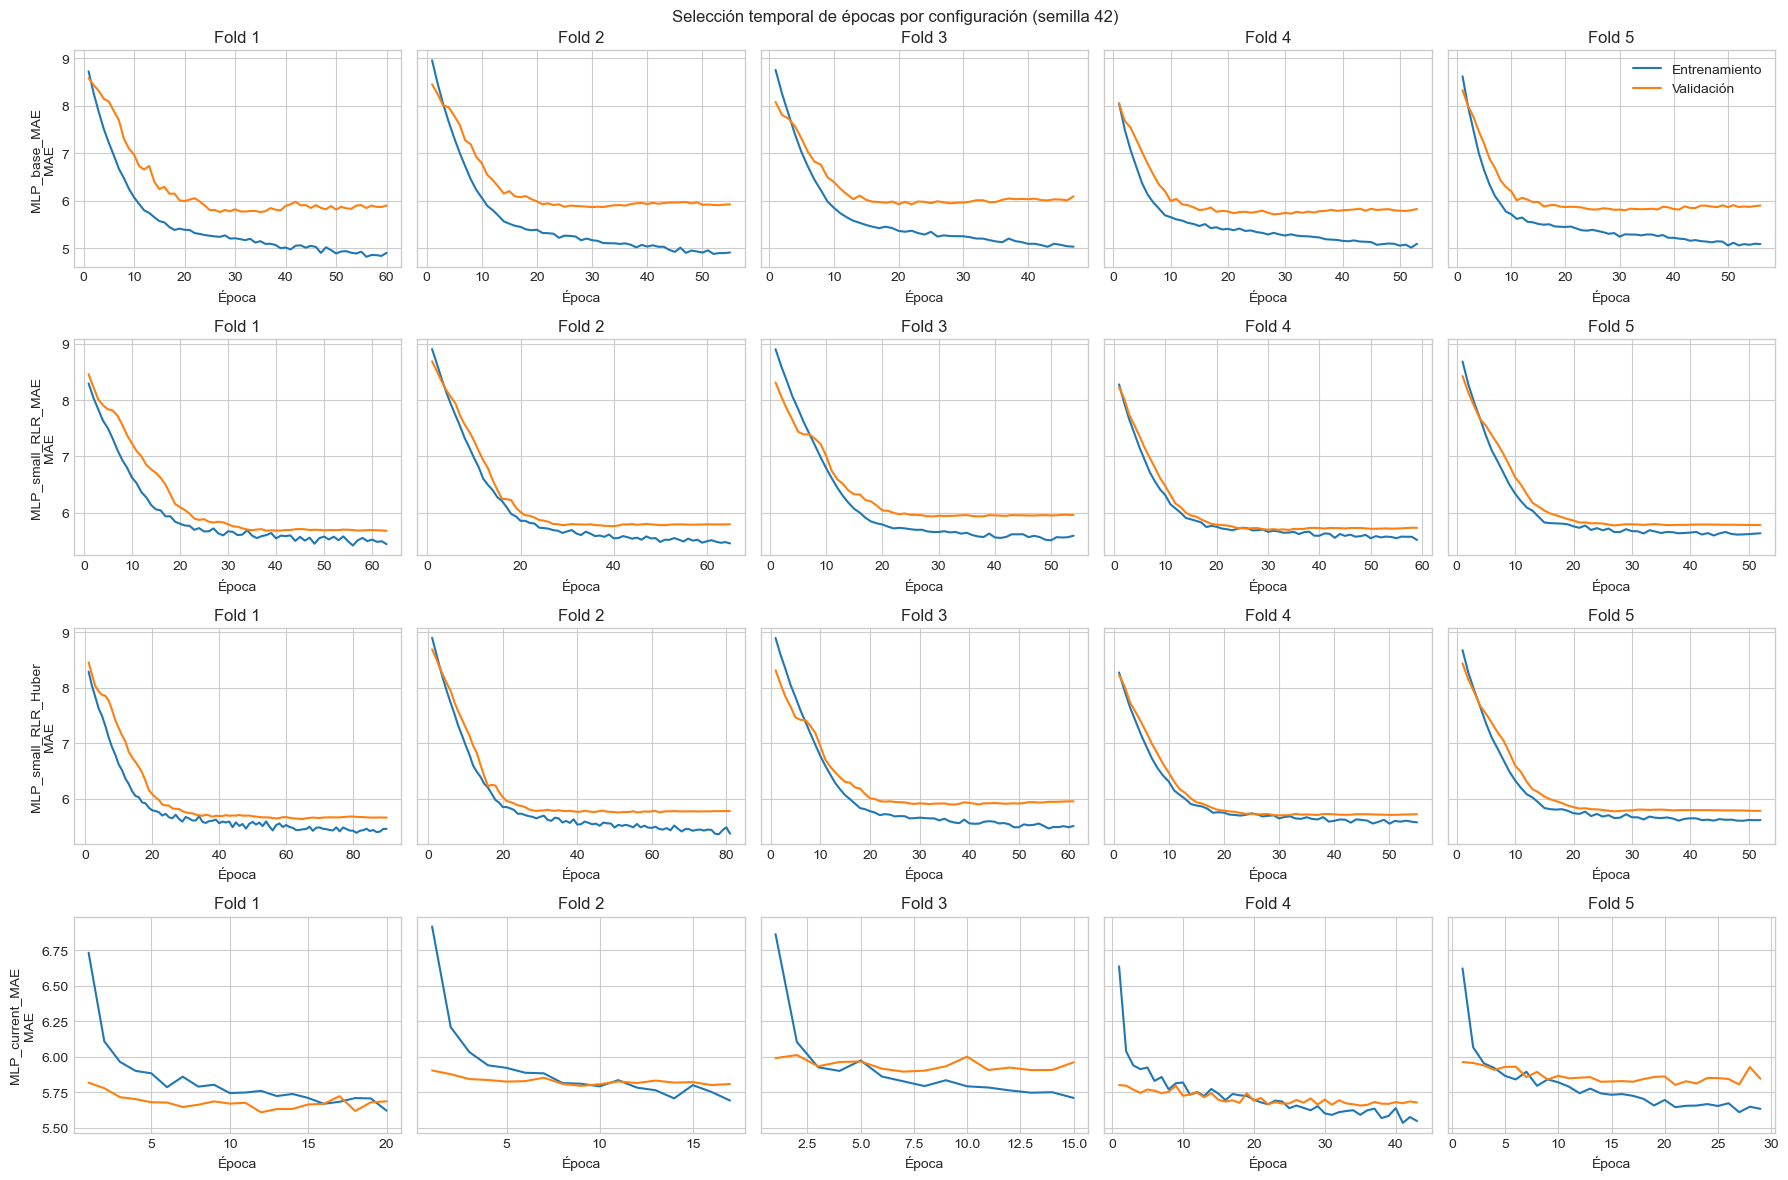

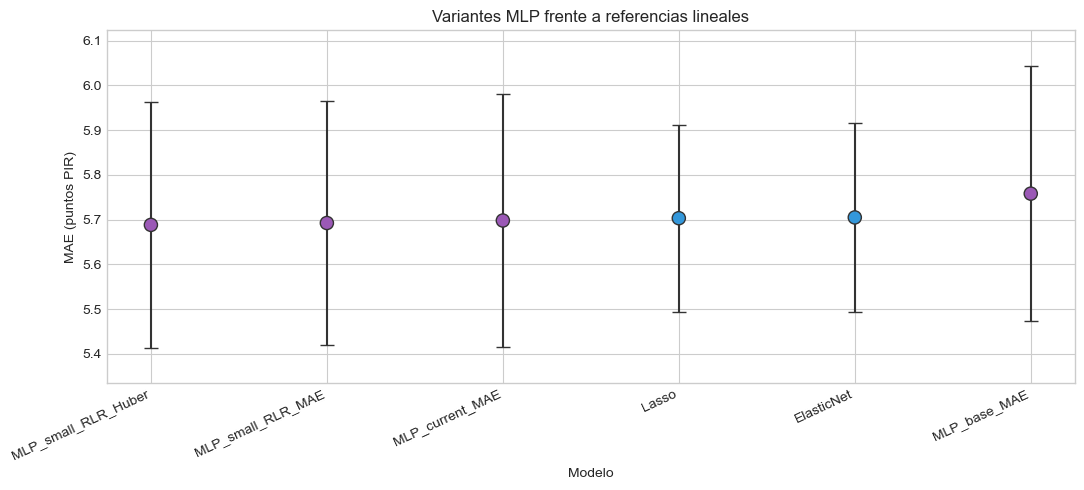

In [6]:
figure_history = history.query("seed == 42").copy()
figure_history.to_csv(TABLE_DIR / "figure_training_curves_source.csv", index=False)
comparison.to_csv(TABLE_DIR / "figure_mlp_comparison_source.csv", index=False)

fig, axes = plt.subplots(4, 5, figsize=(18, 12), sharey="row")
for row, model_name in enumerate([experiment["model"] for experiment in EXPERIMENTS]):
  for column, fold in enumerate(range(1, 6)):
    ax = axes[row, column]
    values = figure_history.query("model == @model_name and fold == @fold")
    ax.plot(values["epoch"], values["train_mae"], label="Entrenamiento")
    ax.plot(values["epoch"], values["validation_mae"], label="Validación")
    ax.set(title=f"Fold {fold}", xlabel="Epoch")
    if column == 0:
        ax.set_ylabel(f"{model_name}\nMAE")
axes[0, -1].legend()
fig.suptitle("Selección temporal de epochs por configuración (semilla 42)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "mlp_training_curves.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#3498db" if model in {"Lasso", "ElasticNet"} else "#9b59b6" for model in comparison["model"]]
positions = np.arange(len(comparison))
ax.errorbar(positions, comparison["mae_mean"], yerr=comparison["mae_std"], fmt="none", ecolor="#333333", capsize=5, zorder=2)
ax.scatter(positions, comparison["mae_mean"], s=90, c=colors, edgecolor="#333333", zorder=3)
ax.set(title="Variantes MLP frente a referencias lineales", xlabel="Modelo", ylabel="MAE (puntos PIR)")
ax.set_xticks(positions, comparison["model"], rotation=25, ha="right")
margin = 0.08
ax.set_ylim((comparison["mae_mean"] - comparison["mae_std"]).min() - margin, (comparison["mae_mean"] + comparison["mae_std"]).max() + margin)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "mlp_vs_linear_mae.png", dpi=160, bbox_inches="tight")
plt.show()

## Resultados e interpretación

La tabla final compara las cuatro MLP con Lasso y ElasticNet mediante MAE, RMSE y R². Las curvas permiten justificar el proceso de entrenamiento y las predicciones individuales quedan disponibles para análisis posteriores. TensorBoard puede abrirse desde el raíz con:

```powershell
python -m tensorboard.main --logdir reports/tensorboard/04_mlp
```

La comparación muestra si las decisiones de arquitectura, regularización y función de pérdida producen mejoras consistentes. El contraste entre `MLP_small_RLR_MAE` y `MLP_small_RLR_Huber` permite estudiar específicamente la pérdida Huber; el resto de diferencias deben atribuirse al conjunto completo de decisiones de cada configuración.

El experimento no pretende explorar todas las arquitecturas posibles. Una reducción pequeña del MAE debe valorarse junto con RMSE, R², estabilidad entre folds y semillas, tiempo de entrenamiento e interpretabilidad. Por ello, la mejor MLP se presenta como parte de una comparación controlada y no como prueba de que una red neuronal sea siempre superior.